<h4>International Migration Trends Analysis (1980–2013): Data Visualization using Python</h4>

<h1>International Migration Trends Analysis (1980–2013): Data Visualization using Python</h1>

<h3>Dataset</h3>

The Dataset is sourced from  United Nations, Department of Economics and Social Affairs, Population Divison(2015)

The data asset contains annual data on the flows of international immigrants as recorded by the countries of destination. The data presents both inflows and outflows according to the place of birth, citizenship or place of previous / next residence both for foreigners and nationals. The current version presents data pertaining to 45 countries.

We will be focusing on the Canadian immigration data.


In [1]:
import numpy as np  
import pandas as pd

Using the excel data import into a dataframe


In [2]:
df_can = pd.read_excel('Canada.xlsx',
    sheet_name='Canada by Citizenship',
    skiprows=range(20),
    skipfooter=2)
df_can.sample(10)

,Type,Coverage,OdName,AREA,AreaName,REG,RegName,DEV,DevName,1980,...,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
48,Immigrants,Foreigners,Democratic People's Republic of Korea,935,Asia,906,Eastern Asia,902,Developing regions,1,...,15,14,10,7,19,11,45,97,66,17
38,Immigrants,Foreigners,"China, Macao Special Administrative Region",935,Asia,906,Eastern Asia,902,Developing regions,0,...,21,21,32,16,12,21,21,13,33,29
90,Immigrants,Foreigners,Kenya,903,Africa,910,Eastern Africa,902,Developing regions,291,...,685,693,622,449,453,489,507,585,725,664
170,Immigrants,Foreigners,Tajikistan,935,Asia,5500,Central Asia,902,Developing regions,0,...,14,85,46,44,15,50,52,47,34,39
94,Immigrants,Foreigners,Lao People's Democratic Republic,935,Asia,920,South-Eastern Asia,902,Developing regions,11,...,38,42,74,53,32,39,54,22,25,15
103,Immigrants,Foreigners,Madagascar,903,Africa,910,Eastern Africa,902,Developing regions,22,...,79,88,96,115,118,169,178,148,165,229
58,Immigrants,Foreigners,Eritrea,903,Africa,910,Eastern Africa,902,Developing regions,0,...,414,528,700,699,799,904,931,1182,1335,1719
150,Immigrants,Foreigners,Sao Tome and Principe,903,Africa,911,Middle Africa,902,Developing regions,0,...,1,1,1,0,0,1,2,0,0,1
36,Immigrants,Foreigners,China,935,Asia,906,Eastern Asia,902,Developing regions,5123,...,36619,42584,33518,27642,30037,29622,30391,28502,33024,34129
44,Immigrants,Foreigners,Croatia,908,Europe,925,Southern Europe,901,Developed regions,0,...,151,128,102,102,131,92,91,135,112,125


Check for basic information from the dataframe

In [3]:
df_can.info()  # Try verbose=False for lesser detailed information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 43 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Type      195 non-null    object
 1   Coverage  195 non-null    object
 2   OdName    195 non-null    object
 3   AREA      195 non-null    int64 
 4   AreaName  195 non-null    object
 5   REG       195 non-null    int64 
 6   RegName   195 non-null    object
 7   DEV       195 non-null    int64 
 8   DevName   195 non-null    object
 9   1980      195 non-null    int64 
 10  1981      195 non-null    int64 
 11  1982      195 non-null    int64 
 12  1983      195 non-null    int64 
 13  1984      195 non-null    int64 
 14  1985      195 non-null    int64 
 15  1986      195 non-null    int64 
 16  1987      195 non-null    int64 
 17  1988      195 non-null    int64 
 18  1989      195 non-null    int64 
 19  1990      195 non-null    int64 
 20  1991      195 non-null    int64 
 21  1992      195 no

Another way to get the columns from the datagrame


In [4]:
df_can.columns

Index([    'Type', 'Coverage',   'OdName',     'AREA', 'AreaName',      'REG',
        'RegName',      'DEV',  'DevName',       1980,       1981,       1982,
             1983,       1984,       1985,       1986,       1987,       1988,
             1989,       1990,       1991,       1992,       1993,       1994,
             1995,       1996,       1997,       1998,       1999,       2000,
             2001,       2002,       2003,       2004,       2005,       2006,
             2007,       2008,       2009,       2010,       2011,       2012,
             2013],
      dtype='object')

Lets look at the indexes

In [5]:
df_can.index

RangeIndex(start=0, stop=195, step=1)

Use the `shape` instance variable to see the dimensions of the data.


In [6]:
df_can.shape

(195, 43)

We can remove unnecessary columns using drop() function


In [7]:
df_can.drop(['AREA','REG','DEV','Type','Coverage'], axis=1, inplace=True)
df_can.head(5)

,OdName,AreaName,RegName,DevName,1980,1981,1982,1983,1984,1985,...,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
0,Afghanistan,Asia,Southern Asia,Developing regions,16,39,39,47,71,340,...,2978,3436,3009,2652,2111,1746,1758,2203,2635,2004
1,Albania,Europe,Southern Europe,Developed regions,1,0,0,0,0,0,...,1450,1223,856,702,560,716,561,539,620,603
2,Algeria,Africa,Northern Africa,Developing regions,80,67,71,69,63,44,...,3616,3626,4807,3623,4005,5393,4752,4325,3774,4331
3,American Samoa,Oceania,Polynesia,Developing regions,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,Andorra,Europe,Southern Europe,Developed regions,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,1,1


In [8]:
df_can.shape

(195, 38)

We can rename the columns so that they make sense.


In [10]:
df_can.rename(columns={'OdName':'Country', 'AreaName':'Continent', 'RegName':'Region'}, inplace=True)
df_can.columns

Index([  'Country', 'Continent',    'Region',   'DevName',        1980,
              1981,        1982,        1983,        1984,        1985,
              1986,        1987,        1988,        1989,        1990,
              1991,        1992,        1993,        1994,        1995,
              1996,        1997,        1998,        1999,        2000,
              2001,        2002,        2003,        2004,        2005,
              2006,        2007,        2008,        2009,        2010,
              2011,        2012,        2013],
      dtype='object')

We will also add a 'Total' column that sums up the total immigrants by country over the entire period 1980 - 2013


In [11]:
df_can['Total'] = df_can.sum(numeric_only=True, axis=1)
#df_can.columns
df_can.sample(10)

,Country,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
47,Czech Republic,Europe,Eastern Europe,Developed regions,0,0,0,0,0,0,...,193,146,137,104,159,168,128,173,174,4192
139,Qatar,Asia,Western Asia,Developing regions,0,0,0,0,0,0,...,11,2,5,9,6,18,3,14,6,157
42,Costa Rica,Latin America and the Caribbean,Central America,Developing regions,28,35,42,51,75,113,...,188,279,281,246,217,190,149,183,122,4489
124,New Zealand,Oceania,Australia and New Zealand,Developed regions,602,480,364,140,164,148,...,370,318,350,480,520,490,375,417,415,10386
56,El Salvador,Latin America and the Caribbean,Central America,Developing regions,110,295,882,2587,2666,2769,...,436,430,929,1115,845,787,691,641,639,54878
96,Lebanon,Asia,Western Asia,Developing regions,1409,1119,1159,789,1253,1683,...,3709,3802,3467,3566,3077,3432,3072,1614,2172,115359
181,Ukraine,Europe,Eastern Europe,Developed regions,0,0,0,0,0,0,...,2270,1973,2218,1937,2367,3159,2515,2265,2487,51410
169,Syrian Arab Republic,Asia,Western Asia,Developing regions,315,419,409,269,264,385,...,1458,1145,1056,919,917,1039,1005,650,1009,31485
50,Denmark,Europe,Northern Europe,Developed regions,272,293,299,106,93,73,...,62,101,97,108,81,92,93,94,81,3901
130,Pakistan,Asia,Southern Asia,Developing regions,978,972,1201,900,668,514,...,14314,13127,10124,8994,7217,6811,7468,11227,12603,241600


check for nulls in the data


In [12]:
df_can.isnull().sum()

Country      0
Continent    0
Region       0
DevName      0
1980         0
1981         0
1982         0
1983         0
1984         0
1985         0
1986         0
1987         0
1988         0
1989         0
1990         0
1991         0
1992         0
1993         0
1994         0
1995         0
1996         0
1997         0
1998         0
1999         0
2000         0
2001         0
2002         0
2003         0
2004         0
2005         0
2006         0
2007         0
2008         0
2009         0
2010         0
2011         0
2012         0
2013         0
Total        0
dtype: int64

We can check the Statistical Summary of numerical data


In [13]:
df_can.describe()

,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,508.394872,566.989744,534.723077,387.435897,376.497436,358.861538,441.271795,691.133333,714.389744,843.241026,...,1320.292308,1266.958974,1191.820513,1246.394872,1275.733333,1420.287179,1262.533333,1313.958974,1320.702564,32867.451282
std,1949.588546,2152.643752,1866.997511,1204.333597,1198.246371,1079.309600,1225.576630,2109.205607,2443.606788,2555.048874,...,4425.957828,3926.717747,3443.542409,3694.573544,3829.630424,4462.946328,4030.084313,4247.555161,4237.951988,91785.498686
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.500000,1.000000,1.000000,...,28.500000,25.000000,31.000000,31.000000,36.000000,40.500000,37.500000,42.500000,45.000000,952.000000
50%,13.000000,10.000000,11.000000,12.000000,13.000000,17.000000,18.000000,26.000000,34.000000,44.000000,...,210.000000,218.000000,198.000000,205.000000,214.000000,211.000000,179.000000,233.000000,213.000000,5018.000000
75%,251.500000,295.500000,275.000000,173.000000,181.000000,197.000000,254.000000,434.000000,409.000000,508.500000,...,832.000000,842.000000,899.000000,934.500000,888.000000,932.000000,772.000000,783.000000,796.000000,22239.500000
max,22045.000000,24796.000000,20620.000000,10015.000000,10170.000000,9564.000000,9470.000000,21337.000000,27359.000000,23795.000000,...,42584.000000,33848.000000,28742.000000,30037.000000,29622.000000,38617.000000,36765.000000,34315.000000,34129.000000,691904.000000


Check how many countries are listed in the dataset

In [18]:
df_can['Country'].unique().size

195

Lets set the country as index in order to easily fetch the data for required country.


In [14]:
df_can.set_index('Country', inplace=True)
#df_can.index.name = None
df_can.sample(5)

,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Country,,,,,,,,,,,,,,,,,,,,,
Saudi Arabia,Asia,Western Asia,Developing regions,0,0,1,4,1,2,5,...,198,252,188,249,246,330,278,286,267,3425
Egypt,Africa,Northern Africa,Developing regions,612,660,755,455,447,348,514,...,2496,2190,2356,3347,3496,5982,4663,5555,4165,72745
Italy,Europe,Southern Europe,Developed regions,1820,2057,1480,820,858,667,731,...,344,325,320,370,429,434,374,440,545,22624
Malaysia,Asia,South-Eastern Asia,Developing regions,786,816,813,448,384,374,425,...,593,580,600,658,640,802,409,358,204,24417
Democratic People's Republic of Korea,Asia,Eastern Asia,Developing regions,1,1,3,1,4,3,0,...,14,10,7,19,11,45,97,66,17,388


Lets check the data from India

In [15]:
#df_can.loc['India']
df_can[df_can.index == 'India']

,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Country,,,,,,,,,,,,,,,,,,,,,
India,Asia,Southern Asia,Developing regions,8880,8670,8147,7338,5704,4211,7150,...,36210,33848,28742,28261,29456,34235,27509,30933,33087,691904


Change the Column data type to String

In [16]:
df_can.columns = list( map(str, df_can.columns) )
df_can.columns

Index(['Continent', 'Region', 'DevName', '1980', '1981', '1982', '1983',
       '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992',
       '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001',
       '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010',
       '2011', '2012', '2013', 'Total'],
      dtype='object')

In [17]:
# having a years list available for each of use later
years = list(map(str, range(1980, 2014)))
years

['1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013']

In [25]:
# Way to filter data based on multiple conditions

df_can['1980'] > 100 
df_can[    df_can['1980'] > 100    ]

,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Country,,,,,,,,,,,,,,,,,,,,,
Argentina,Latin America and the Caribbean,South America,Developing regions,368,426,626,241,237,196,213,...,1153,847,620,540,467,459,278,263,282,19596
Australia,Oceania,Australia and New Zealand,Developed regions,702,639,484,317,317,319,356,...,909,875,1033,1018,1018,933,851,982,1121,23829
Austria,Europe,Western Europe,Developed regions,234,238,201,117,127,165,196,...,122,102,98,91,109,124,84,102,90,4985
Barbados,Latin America and the Caribbean,Caribbean,Developing regions,372,376,299,244,265,285,251,...,111,97,130,134,125,121,97,132,97,6923
Belgium,Europe,Western Europe,Developed regions,511,540,519,297,183,181,197,...,400,302,363,335,358,363,332,402,379,10762
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
United Republic of Tanzania,Africa,Eastern Africa,Developing regions,635,832,621,474,473,460,403,...,274,291,195,230,136,200,215,224,182,12496
United States of America,Northern America,Northern America,Developed regions,9378,10030,9074,7100,6661,6543,7074,...,8394,9613,9463,10190,8995,8142,7676,7891,8501,241122
Uruguay,Latin America and the Caribbean,South America,Developing regions,128,132,146,105,90,92,137,...,217,175,147,160,99,93,81,47,58,4715


In [18]:
# Filter rows based on Multiple conditions
df_can[ ( df_can['Continent']=='Asia' ) & (df_can['Region']=='Southern Asia') ]

,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Country,,,,,,,,,,,,,,,,,,,,,
Afghanistan,Asia,Southern Asia,Developing regions,16,39,39,47,71,340,496,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
Bangladesh,Asia,Southern Asia,Developing regions,83,84,86,81,98,92,486,...,4171,4014,2897,2939,2104,4721,2694,2640,3789,65568
Bhutan,Asia,Southern Asia,Developing regions,0,0,0,0,1,0,0,...,5,10,7,36,865,1464,1879,1075,487,5876
India,Asia,Southern Asia,Developing regions,8880,8670,8147,7338,5704,4211,7150,...,36210,33848,28742,28261,29456,34235,27509,30933,33087,691904
Iran (Islamic Republic of),Asia,Southern Asia,Developing regions,1172,1429,1822,1592,1977,1648,1794,...,5837,7480,6974,6475,6580,7477,7479,7534,11291,175923
Maldives,Asia,Southern Asia,Developing regions,0,0,0,1,0,0,0,...,0,0,2,1,7,4,3,1,1,30
Nepal,Asia,Southern Asia,Developing regions,1,1,6,1,2,4,13,...,607,540,511,581,561,1392,1129,1185,1308,10222
Pakistan,Asia,Southern Asia,Developing regions,978,972,1201,900,668,514,691,...,14314,13127,10124,8994,7217,6811,7468,11227,12603,241600
Sri Lanka,Asia,Southern Asia,Developing regions,185,371,290,197,1086,845,1838,...,4930,4714,4123,4756,4547,4422,3309,3338,2394,148358


<h3>Data Visualization</h3>

### Matplotlib.Pyplot


Matplotlib is a versatile and widely-used Python library for creating static, animated, and interactive visualizations. Developed by John D. Hunter in 2003, it provides a high-quality plotting framework that enables users to generate a diverse range of charts, graphs, and plots. With a syntax similar to MATLAB, Matplotlib is seamlessly integrated into the scientific computing ecosystem and offers extensive customization options for creating publication-quality visuals in various formats. Whether for data exploration, analysis, or presentation, Matplotlib remains a go-to tool for data visualization in the Python programming language.

Importing `matplotlib` and `matplotlib.pyplot`


In [27]:
#The %matplotlib inline command is specific to Jupyter Notebooks and is used to render Matplotlib plots directly within the notebook cells
%matplotlib inline 

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.style.use(['ggplot']) 

## Line Chart

Line chart is a very common chart type used when we have continuous data specially over time.

Lets see how immigration has been over time from India

In [28]:
ind = df_can.loc['India',years]
ind

1980     8880
1981     8670
1982     8147
1983     7338
1984     5704
1985     4211
1986     7150
1987    10189
1988    11522
1989    10343
1990    12041
1991    13734
1992    13673
1993    21496
1994    18620
1995    18489
1996    23859
1997    22268
1998    17241
1999    18974
2000    28572
2001    31223
2002    31889
2003    27155
2004    28235
2005    36210
2006    33848
2007    28742
2008    28261
2009    29456
2010    34235
2011    27509
2012    30933
2013    33087
Name: India, dtype: object

Lets add the line chart for this


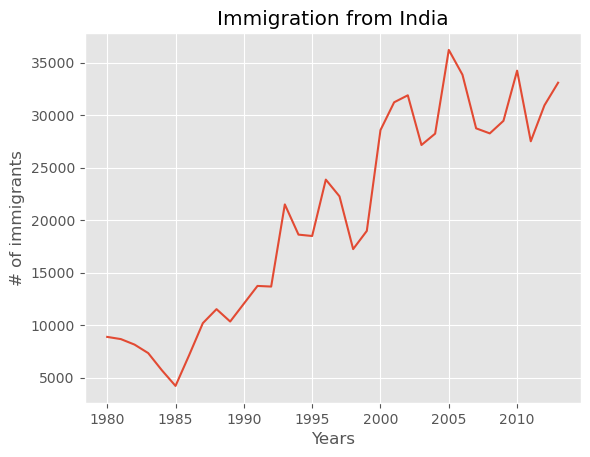

In [29]:
ind.plot(kind='line')
plt.title('Immigration from India')
plt.ylabel('# of immigrants')
plt.xlabel('Years')

plt.show()

Lets compare the immigration from different countries

In [30]:
df_CI = df_can.loc[['India', 'China'], years]
df_CI

,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
Country,,,,,,,,,,,,,,,,,,,,,
India,8880,8670,8147,7338,5704,4211,7150,10189,11522,10343,...,28235,36210,33848,28742,28261,29456,34235,27509,30933,33087
China,5123,6682,3308,1863,1527,1816,1960,2643,2758,4323,...,36619,42584,33518,27642,30037,29622,30391,28502,33024,34129


In [33]:
df_CI = df_CI.transpose()  # Transposing the data to make sure Index(i.e. x-axis has years) and Columns(i.e. country wise cnts on y-axis)
df_CI.head()

Country,India,China
1980,8880,5123
1981,8670,6682
1982,8147,3308
1983,7338,1863
1984,5704,1527


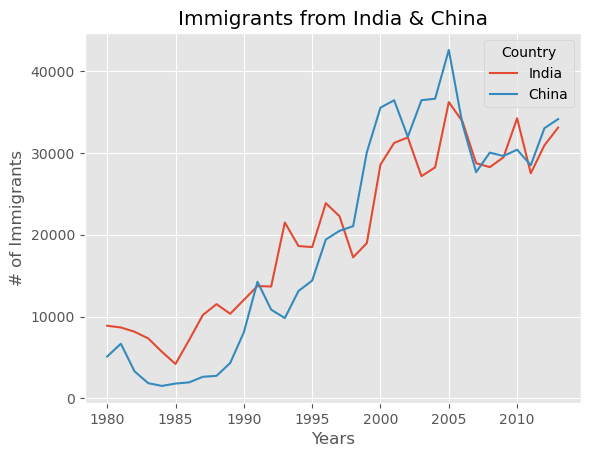

In [34]:
df_CI.plot(kind='line')

plt.title('Immigrants from India & China')
plt.ylabel('# of Immigrants')
plt.xlabel('Years')

plt.show()

Lets compare trend of top 3 countries that contributed the most to immigration to Canada.


In [37]:
df_can.sort_values(by='Total', ascending=False, axis=0, inplace=True)
df_can.head(5)

#df_can
# get the top 3 entries
df_top3 = df_can.head(3)
df_top3

# transpose the dataframe
df_top3 = df_top3[years].transpose() 
df_top3

Country,India,China,United Kingdom of Great Britain and Northern Ireland
1980,8880,5123,22045
1981,8670,6682,24796
1982,8147,3308,20620
1983,7338,1863,10015
1984,5704,1527,10170
1985,4211,1816,9564
1986,7150,1960,9470
1987,10189,2643,21337
1988,11522,2758,27359
1989,10343,4323,23795


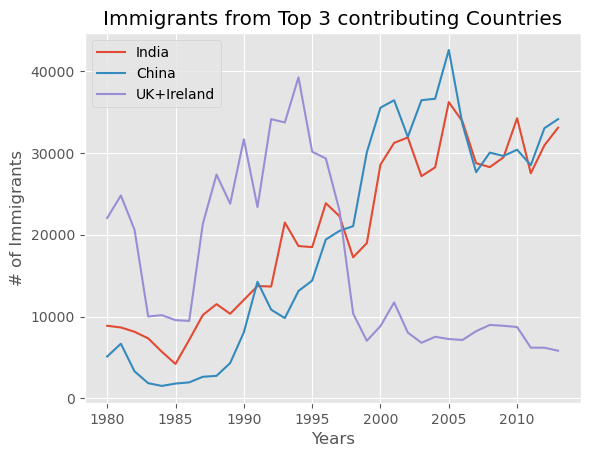

In [38]:
df_top3.rename(columns={'United Kingdom of Great Britain and Northern Ireland':'UK+Ireland'},inplace=True)

df_top3.plot(kind='line')

plt.title('Immigrants from Top 3 contributing Countries')
plt.ylabel('# of Immigrants')
plt.xlabel('Years')
plt.legend(loc='upper left')
plt.show()

### Area Chart


It is similar to a line chart but with the area below the line filled with color. Used for comparison of multiple trends.

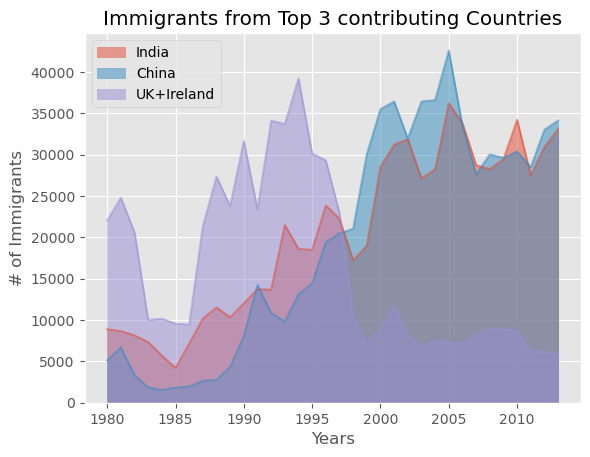

In [41]:
df_top3.plot(kind='area',
             stacked=False)

plt.title('Immigrants from Top 3 contributing Countries')
plt.ylabel('# of Immigrants')
plt.xlabel('Years')
plt.legend(loc='upper left')
plt.show()


### Stacked Area Chart

In a stacked area chart, multiple datasets are stacked on top of each other, and the filled areas overlap. Each component's area contributes to the cumulative total at each point along the x-axis.

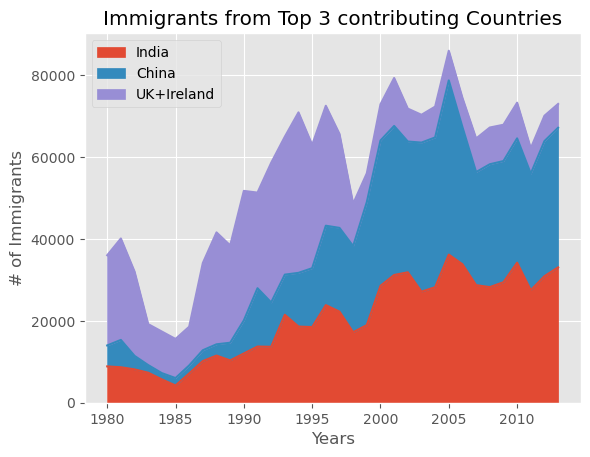

In [42]:
df_top3.plot(kind='area',
             stacked=True)

plt.title('Immigrants from Top 3 contributing Countries')
plt.ylabel('# of Immigrants')
plt.xlabel('Years')
plt.legend(loc='upper left')
plt.show()

`Matplotlib.pyplot` is a module within the Matplotlib library that provides a collection of functions that closely resemble the MATLAB plotting style. It is commonly used for creating static, interactive, and animated visualizations.

### Histogram

A histogram is a graphical representation of the distribution of a dataset. It is used to visualize the underlying frequency distribution of a set of continuous or discrete data. Histograms provide insights into the shape, center, and spread of the data, making them particularly useful for understanding the distribution of numerical variables.

Plot a histogram of # of countries against # of Immigrants

In [43]:
df_can[ (df_can['1980'] > 20000) & (df_can['1980'] < 50000)]

,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Country,,,,,,,,,,,,,,,,,,,,,
United Kingdom of Great Britain and Northern Ireland,Europe,Northern Europe,Developed regions,22045,24796,20620,10015,10170,9564,9470,...,7258,7140,8216,8979,8876,8724,6204,6195,5827,551500


In [45]:
df_can[ (df_can['1980'] < 1000) ]

,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Country,,,,,,,,,,,,,,,,,,,,,
Pakistan,Asia,Southern Asia,Developing regions,978,972,1201,900,668,514,691,...,14314,13127,10124,8994,7217,6811,7468,11227,12603,241600
Sri Lanka,Asia,Southern Asia,Developing regions,185,371,290,197,1086,845,1838,...,4930,4714,4123,4756,4547,4422,3309,3338,2394,148358
Poland,Europe,Eastern Europe,Developed regions,863,2930,5881,4546,3588,2819,4808,...,1405,1263,1235,1267,1013,795,720,779,852,139241
Romania,Europe,Eastern Europe,Developed regions,375,438,583,543,524,604,656,...,5048,4468,3834,2837,2076,1922,1776,1588,1512,93585
Egypt,Africa,Northern Africa,Developing regions,612,660,755,455,447,348,514,...,2496,2190,2356,3347,3496,5982,4663,5555,4165,72745
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
New Caledonia,Oceania,Melanesia,Developing regions,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,2,5
San Marino,Europe,Southern Europe,Developed regions,1,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,5
Marshall Islands,Oceania,Micronesia,Developing regions,0,0,0,0,0,0,0,...,0,0,2,0,0,0,0,0,0,2


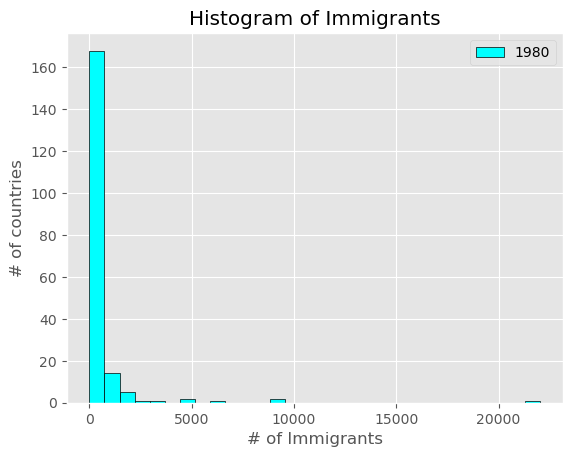

In [49]:
#Plotting a  histogram
plt.hist(df_can['1980'], bins=30, color=['cyan'], edgecolor='black')
 
# Adding labels and title
plt.xlabel('# of Immigrants')
plt.ylabel('# of countries')
plt.title('Histogram of Immigrants')
plt.legend(['1980']) 
# Display the plot
plt.show()

Multi Histograms in same plot

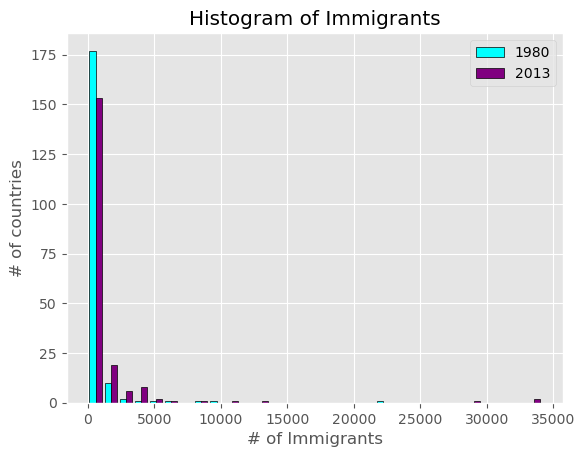

In [50]:
#Plotting a  histogram
plt.hist(df_can[['1980','2013']], bins=30, color=['cyan', 'Purple'], edgecolor='black')
 
# Adding labels and title
plt.xlabel('# of Immigrants')
plt.ylabel('# of countries')
plt.title('Histogram of Immigrants')
plt.legend(['1980', '2013']) 
# Display the plot
plt.show()

### Bar Chart

A bar chart is a type of data visualization that presents categorical data with rectangular bars
Bar charts are effective for displaying the distribution of data across discrete categories 

Lets see how the immigration numbers have increased from India over the period through bar chart

In [51]:
df_can.loc['India',years]

1980     8880
1981     8670
1982     8147
1983     7338
1984     5704
1985     4211
1986     7150
1987    10189
1988    11522
1989    10343
1990    12041
1991    13734
1992    13673
1993    21496
1994    18620
1995    18489
1996    23859
1997    22268
1998    17241
1999    18974
2000    28572
2001    31223
2002    31889
2003    27155
2004    28235
2005    36210
2006    33848
2007    28742
2008    28261
2009    29456
2010    34235
2011    27509
2012    30933
2013    33087
Name: India, dtype: object

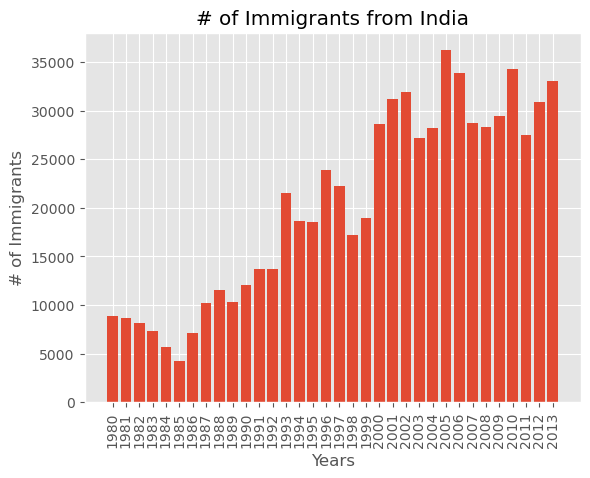

In [52]:
plt.bar(years, df_can.loc['India',years])
 
plt.xlabel("Years") 
 
plt.ylabel("# of Immigrants")   
plt.title("# of Immigrants from India")
plt.xticks(rotation=90)
plt.show()

Plot multiple plot in an area

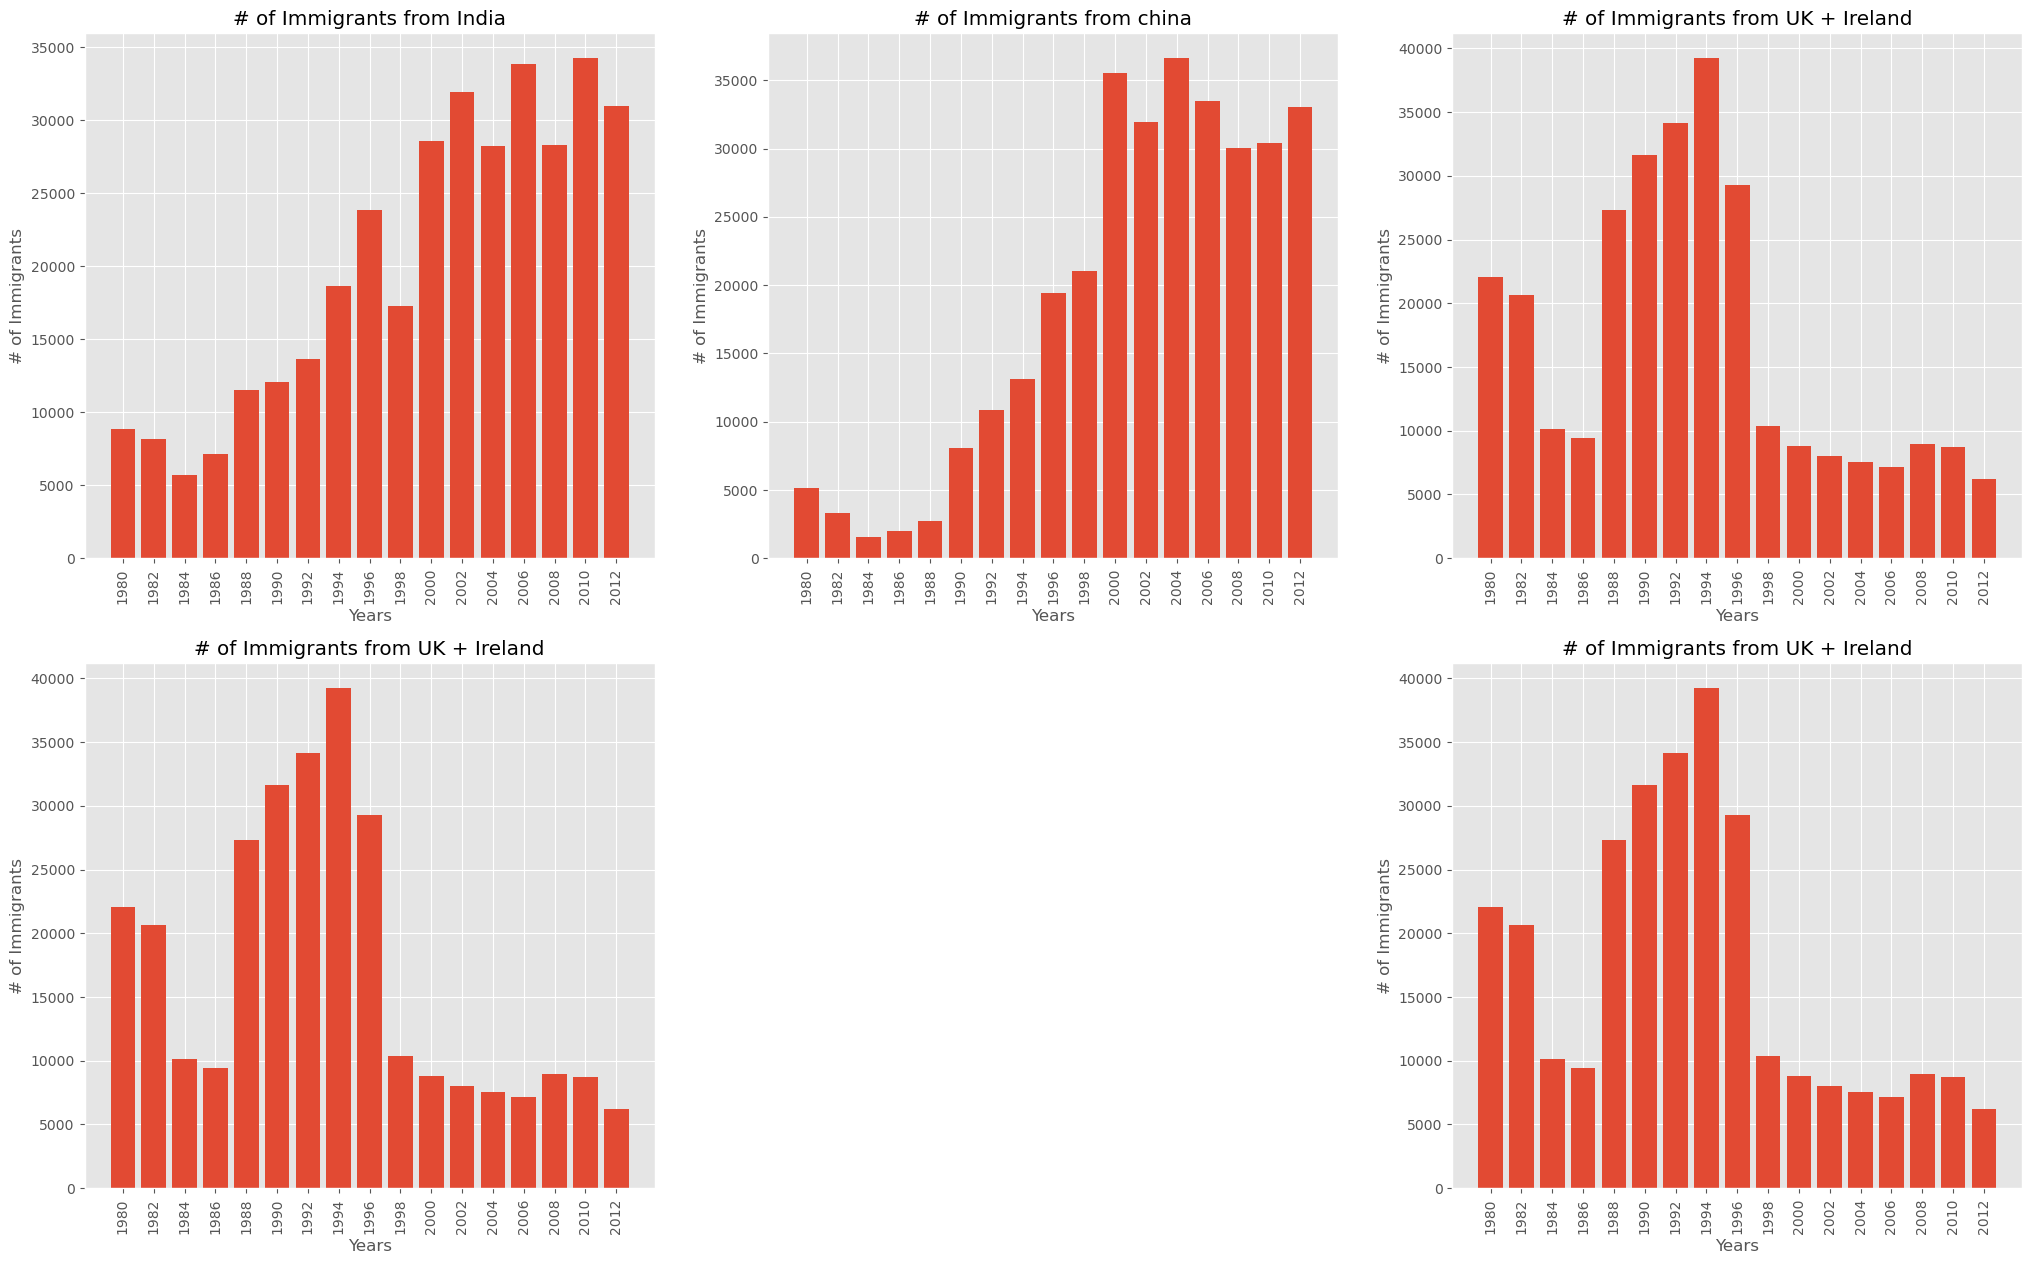

In [56]:
plt.figure(figsize=(25, 15))

plt.subplot(231)
plt.bar(years[::2], df_can.loc['India',years[::2]])
plt.title("# of Immigrants from India")
plt.xlabel("Years") 
plt.ylabel("# of Immigrants")
plt.xticks(rotation=90)

plt.subplot(232)
plt.bar(years[::2], df_can.loc['China',years[::2]])
plt.title("# of Immigrants from china")
plt.xlabel("Years") 
plt.ylabel("# of Immigrants") 
plt.xticks(rotation=90)
#plt.suptitle('India vs China')

plt.subplot(233)
plt.bar(years[::2], df_can.loc['United Kingdom of Great Britain and Northern Ireland',years[::2]])
plt.title("# of Immigrants from UK + Ireland")
plt.xlabel("Years") 
plt.ylabel("# of Immigrants") 
plt.xticks(rotation=90)

plt.subplot(234)
plt.bar(years[::2], df_can.loc['United Kingdom of Great Britain and Northern Ireland',years[::2]])
plt.title("# of Immigrants from UK + Ireland")
plt.xlabel("Years") 
plt.ylabel("# of Immigrants") 
plt.xticks(rotation=90)

plt.subplot(236)
plt.bar(years[::2], df_can.loc['United Kingdom of Great Britain and Northern Ireland',years[::2]])
plt.title("# of Immigrants from UK + Ireland")
plt.xlabel("Years") 
plt.ylabel("# of Immigrants") 
plt.xticks(rotation=90)
plt.show()
 
    


### Horizontal Bar Chart

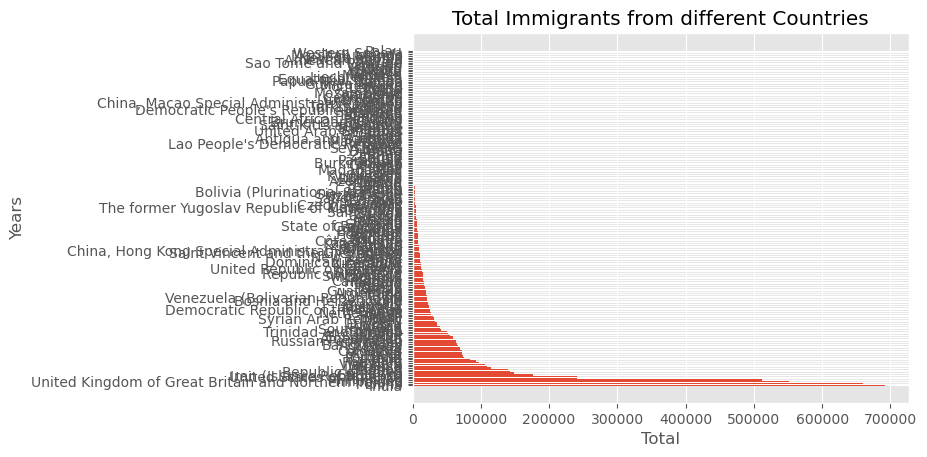

In [57]:
plt.barh(df_can.index,df_can['Total'])
 
plt.xlabel("Total") 
plt.ylabel("Years")   
plt.title("Total Immigrants from different Countries")
#plt.xticks(rotation=90)
plt.show()

In [57]:
df_can.index.values[1:10].tolist()

['China',
 'United Kingdom of Great Britain and Northern Ireland',
 'Philippines',
 'Pakistan',
 'United States of America',
 'Iran (Islamic Republic of)',
 'Sri Lanka',
 'Republic of Korea',
 'Poland']

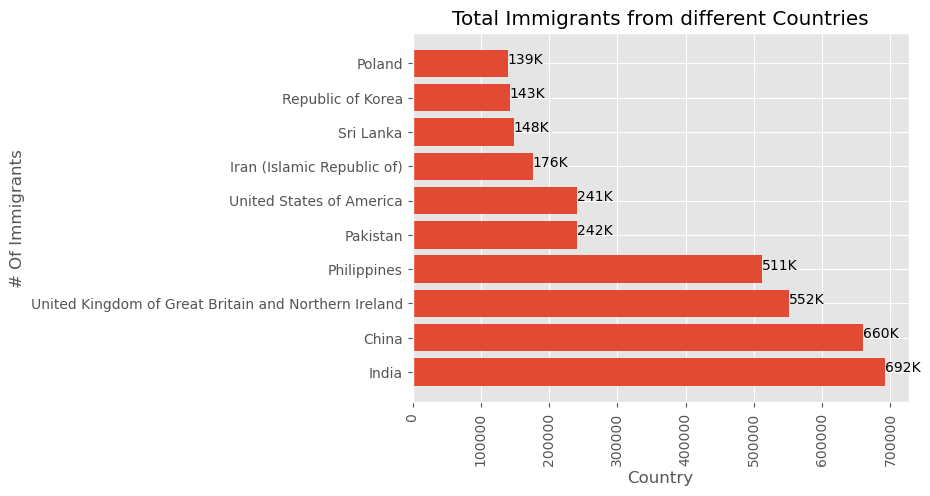

In [58]:
df_can.sort_values(by='Total', ascending=False, inplace=True)

plt.barh(df_can.index.values[0:10].tolist(),df_can['Total'][0:10])
 
plt.xlabel("Country") 
 
plt.ylabel("# Of Immigrants")   
plt.title("Total Immigrants from different Countries")
plt.xticks(rotation=90)


for index, value in enumerate(df_can['Total'][0:10]):
    plt.text(value, index,
             str(round(value/1000))+'K')

plt.show()

### Stacked Bar Chart

A stacked bar chart is a variation of the traditional bar chart where multiple datasets are represented as individual bars, and each bar is further divided into segments that represent different components or categories

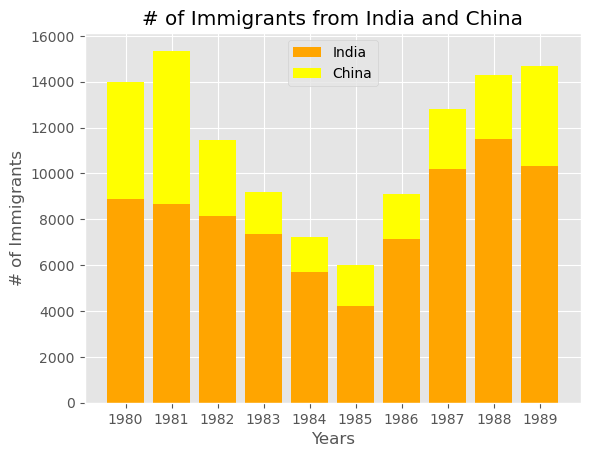

In [59]:
plt.bar(years[0:10], df_can.loc['India',years[0:10]],color='orange')

plt.bar(years[0:10], df_can.loc['China',years[0:10]], bottom=df_can.loc['India',years[0:10]],color='yellow')
 
plt.xlabel("Years") 
 
plt.ylabel("# of Immigrants")   
plt.title("# of Immigrants from India and China")
plt.legend(["India", "China"])

#plt.xticks(rotation=90)
plt.show()

### Pie Chart

A pie chart is a circular statistical graphic that is divided into slices to illustrate numerical proportions

In [61]:
df_grouped = df_can[['Continent','Total']].groupby('Continent').sum('Total')
df_grouped

,Total
Continent,
Africa,618948
Asia,3317794
Europe,1410947
Latin America and the Caribbean,765148
Northern America,241142
Oceania,55174


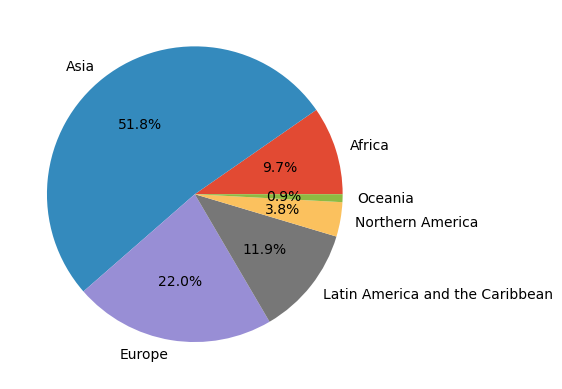

In [62]:
plt.pie(df_grouped['Total'], labels=df_grouped.index, autopct='%1.1f%%')
 
# show plot
plt.show()

### Box Plot

A box plot, also known as a box-and-whisker plot, is a statistical visualization that provides a summary of the distribution of a dataset. It displays key statistical measures such as the median, quartiles, and potential outliers. Box plots are particularly useful for comparing the distribution of multiple datasets or identifying the spread and central tendency of a single dataset.

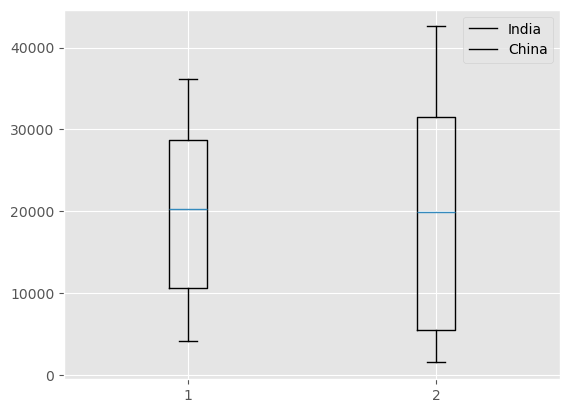

In [63]:
plt.boxplot( [ df_can.loc['India',years], df_can.loc['China',years]  ])
             #,df_can.loc['China',years]]
# show plot
plt.legend(['India','China'])
plt.show()


### Scatter Plot

A scatter plot is a type of data visualization that displays individual data points on a two-dimensional graph. Each point on the plot represents the values of two variables, allowing for the observation of patterns, trends, and relationships between the variables. Scatter plots are commonly used to identify correlations, outliers, and the overall distribution of the data.

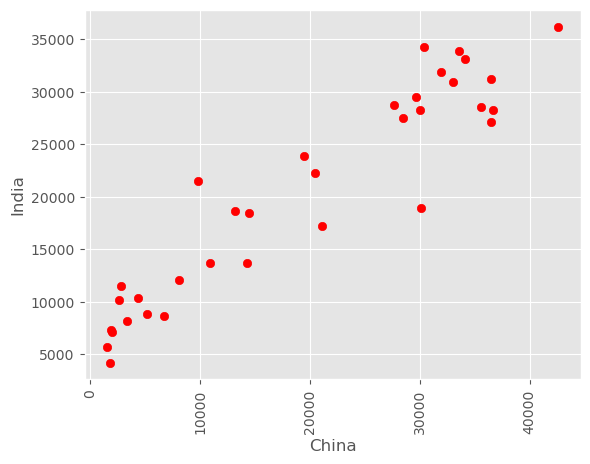

In [64]:
plt.scatter(df_can.loc['China',years], df_can.loc['India',years], c ="red")

plt.xlabel("China")
plt.ylabel("India")
plt.xticks(rotation=90)
plt.show()

### Advance Visualization using Maps

#### Using Folium for Map Visualizations

Folium is a Python library used for creating interactive web maps. It is built on top of the Leaflet JavaScript library and allows users to create maps with various features and interactivity. Folium simplifies the process of creating maps and provides a Pythonic way to visualize geographic data.

In [1]:
pip install folium

Note: you may need to restart the kernel to use updated packages.


In [2]:
import folium

world_map = folium.Map()
# display world map
world_map

#### Lets map all the stops of metro stations in Hyderabad

In [3]:
import pandas as pd

# Below file Contains data provided by Hyderabad Metro Rail Ltd.

df=pd.read_csv('stops.csv')
df
locations = df[['stop_lat', 'stop_lon']]
locationlist = locations.values.tolist()

In [4]:
map = folium.Map(location=[17.4, 78.4], zoom_start=12)
for point in range(0, len(locationlist)):
    folium.Marker(locationlist[point], popup=df['stop_name'][point]).add_to(map)
map